In [10]:
import os
import sys
import datetime
import pandas as pd
from plotnine import ggplot
import matplotlib as mpl
import matplotlib.pyplot as plt
print("Python version= {0}".format(sys.version_info))
print("Pandas version= {0}".format(pd.__version__))
print("Datetime= {0}".format(datetime.datetime.now()))

Python version= sys.version_info(major=3, minor=8, micro=5, releaselevel='final', serial=0)
Pandas version= 1.1.3
Datetime= 2020-10-18 23:42:37.509190


In [11]:
sys.path.append('../../fredapi')
from fredapi import fred
import fredapi
print(fredapi.__version__)
Fred = fred.Fred(api_key_file="fred_api.key")

0.4.2


In [12]:
fred_ids = pd.read_csv('fred_ids.csv', index_col=None)
fred_ids

,series_id,description
0,USPRIV,BLS private
1,NPPTTL,ADP
2,ICSA,Initial Claims
3,CCSA,Continued Claims
4,JTS1000JOL,Job Openings: Total Private
5,JTS1000HIL,Hires: Total Private
6,JTS1000TSL,Total Separations: Total Private
7,CSCICP03USM665S,OECD US Consumer Confidence
8,BSCICP03USM665S,OECD Business Confidence


In [13]:
dfs = []
obs_start = "2007-01-01"
obs_end = datetime.date.today()
for ser in fred_ids.itertuples():
    print(ser.series_id, end=', ')
    all_df = Fred.get_series_all_releases(series_id=ser.series_id, observation_start=obs_start, observation_end=obs_end)
    tdf = all_df.sort_values(by="realtime_start", ascending=True).groupby(by="date").head(1)   
    tdf['series_id'] = ser.series_id
    print("rows= {0}".format(tdf.shape[0]))
    dfs.append(tdf)

USPRIV, rows= 165
NPPTTL, rows= 165
ICSA, rows= 719
CCSA, rows= 718
JTS1000JOL, rows= 164
JTS1000HIL, rows= 164
JTS1000TSL, rows= 164
CSCICP03USM665S, rows= 165
BSCICP03USM665S, rows= 165


In [14]:
df = pd.concat(dfs)
df.sort_values(by="date", inplace=True)
df.head(4)
df['series_id'].unique()
df['date'] = df['date'].dt.date
print(df.tail(12))
print(df.dtypes)


     realtime_start        date       value        series_id
9407     2020-10-09  2020-09-01     98.8578  CSCICP03USM665S
4161     2020-09-17  2020-09-05  1.2628e+07             CCSA
3850     2020-09-10  2020-09-05      884000             ICSA
3852     2020-09-17  2020-09-12      860000             ICSA
4163     2020-09-24  2020-09-12   1.258e+07             CCSA
4165     2020-10-01  2020-09-19  1.1767e+07             CCSA
3854     2020-09-24  2020-09-19      870000             ICSA
4167     2020-10-08  2020-09-26  1.0976e+07             CCSA
3856     2020-10-01  2020-09-26      837000             ICSA
4169     2020-10-15  2020-10-03  1.0018e+07             CCSA
3858     2020-10-08  2020-10-03      840000             ICSA
3860     2020-10-15  2020-10-10      898000             ICSA
realtime_start    datetime64[ns]
date                      object
value                     object
series_id                 object
dtype: object


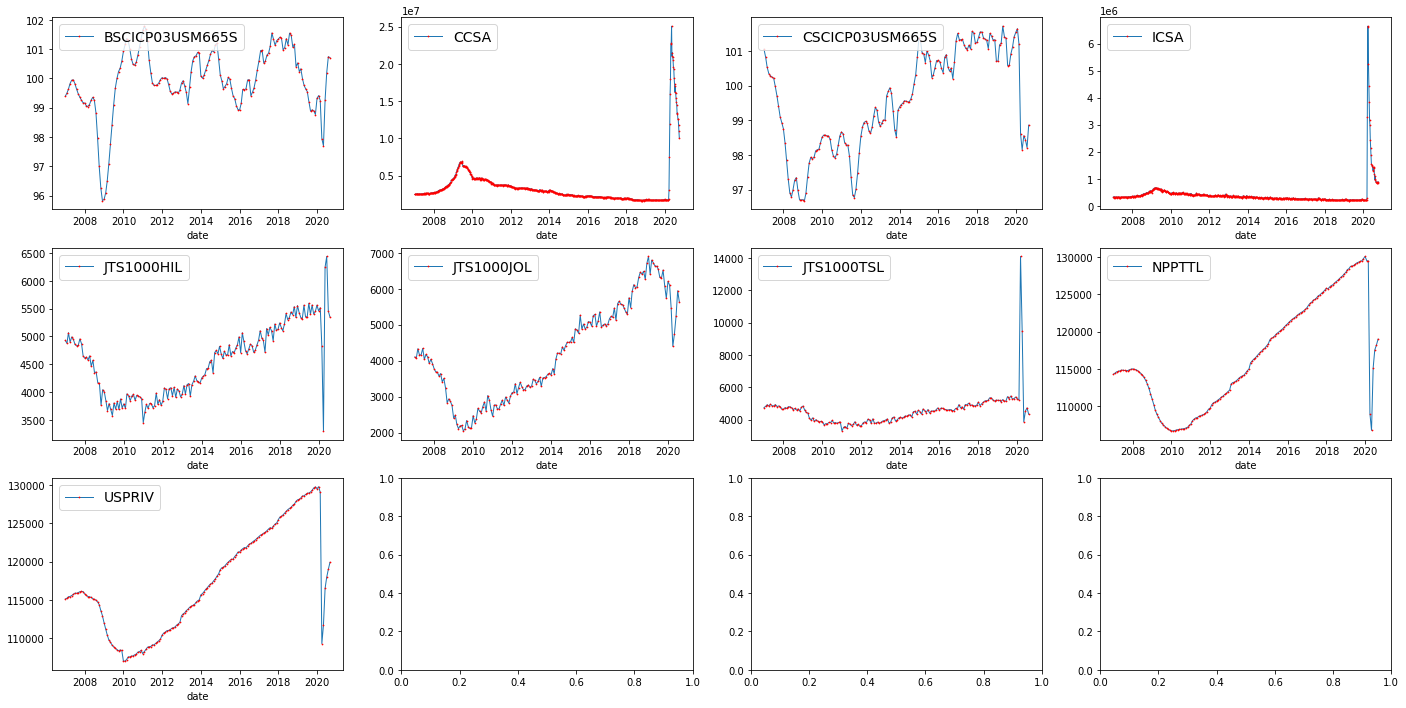

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=[24,12])
gdf = df.groupby(by='series_id')
for i, (key, group) in enumerate(gdf):
    row = i // 4
    col = i % 4
    ax = axs[row][col]
    group.plot(ax=ax, kind='line', x='date', y='value',linestyle='-', marker='o', lw=1,
               mec='red', mfc='black', ms=0.75, label=key)
    ax.legend(loc=2, prop={'size': 14})    

plt.show()

In [ ]:
import seaborn as sns
sns.set_theme(style="darkgrid")
df.dtypes

In [ ]:
df.dtypes

In [ ]:
g = sns.FacetGrid(df, col="series_id",  height=2)
g.map(sns.pointplot, 'date', 'value')
g

In [ ]:
from plotnine import ggplot, geom_line, aes, facet_grid
ggplot(df, aes(x='date', y='value')) + geom_line() + facet_grid('series_id ~ .')